# Mnist 데이터 학습

## 1. 패키지 설정

In [65]:
import tensorflow as tf
from tensorflow import keras
from keras import datasets
from keras import Input
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
import random
import os

In [66]:
# -----------------------
# 재현성
# -----------------------
SEED = int(os.environ.get("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. 데이터 로드

In [67]:
(train_data, train_label), (test_data, test_label) = datasets.mnist.load_data()

In [68]:
print(train_data.shape)
print(train_label.shape)
print(test_data.shape)
print(test_label.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


## 3. 데이터 전처리

In [69]:
train_data = train_data / 255.0
test_data = test_data / 255.0

print(train_data[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

## 4. 모델 설계

In [70]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model



model = build_model()

## 5. 모델 학습

In [71]:
history = model.fit(train_data, train_label, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9005 - loss: 0.3226 - val_accuracy: 0.9835 - val_loss: 0.0570
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9839 - loss: 0.0499 - val_accuracy: 0.9883 - val_loss: 0.0434
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9897 - loss: 0.0324 - val_accuracy: 0.9900 - val_loss: 0.0388
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9930 - loss: 0.0233 - val_accuracy: 0.9885 - val_loss: 0.0467
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9949 - loss: 0.0161 - val_accuracy: 0.9892 - val_loss: 0.0424
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9953 - loss: 0.0137 - val_accuracy: 0.9900 - val_loss: 0.0437
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9958 - loss: 0.0120 - val_accuracy: 0.9898 - val_loss: 0.0440
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9968 - loss: 0.0092 -

## 모델 평가 및 학습 결과 시각화

In [72]:
model.evaluate(test_data, test_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0583


[0.04958265647292137, 0.9896000027656555]

Training history plot saved to history.jpg


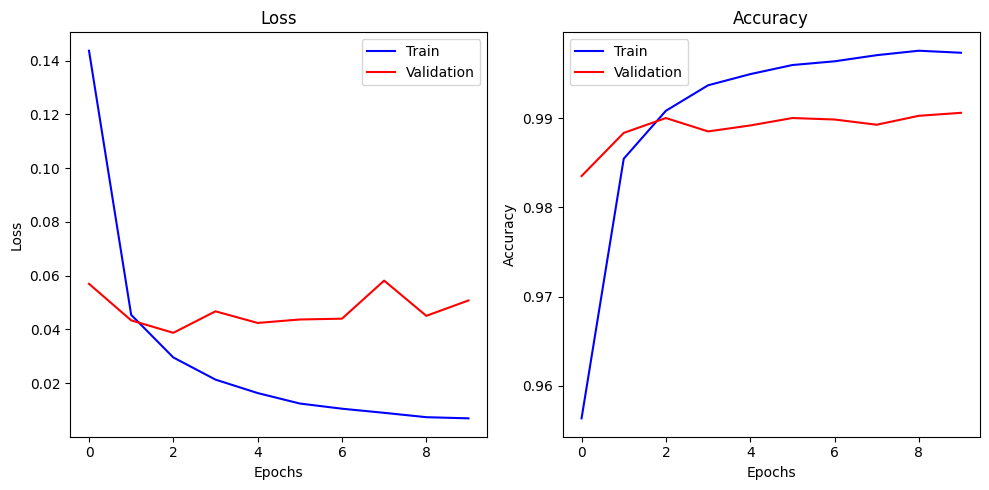

In [73]:
def plot_history(history, out_path="history.jpg"):
    plt.figure(figsize=(10,5))

    # ============ Loss ============
    plt.subplot(1,2,1)
    plt.title("Loss")
    plt.plot(history.history["loss"], c="blue", label="Train")
    plt.plot(history.history["val_loss"], c="red", label="Validation")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # ============ Accuracy ============
    plt.subplot(1,2,2)
    plt.title("Accuracy")
    plt.plot(history.history["accuracy"], c="blue", label="Train")
    plt.plot(history.history["val_accuracy"], c="red", label="Validation")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()


    # ============ Save & Show ============
    plt.savefig(out_path)
    print(f"Training history plot saved to {out_path}")

    plt.tight_layout()
    plt.show()


plot_history(history)

In [74]:
result = model.predict(test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


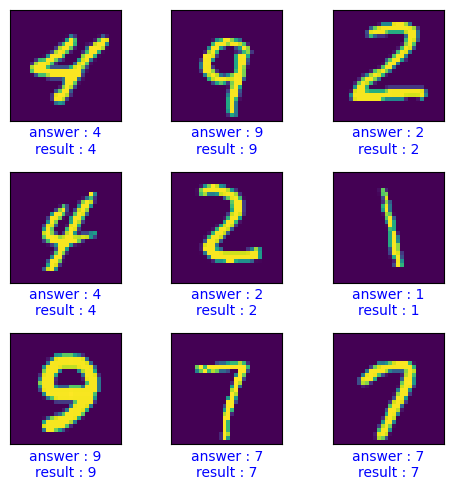

In [104]:
def draw_graph(data, label, result):
    result = np.argmax(result)
    color = "b" if label == result else "r"
    img =  plt.imshow(data * 255)
    plt.xlabel(f"answer : {label}\nresult : {result}", c=color)
    plt.xticks([])
    plt.yticks([])
    

rand_num = random.sample(range(len(test_data)), k=9)

plt.figure(figsize=(5,5))
for idx, num in enumerate(rand_num):
    plt.subplot(3,3,idx+1)
    draw_graph(test_data[num], test_label[num], result[num])

plt.tight_layout()
plt.show()